# 01 — Open-Meteo Agri-Climate Data Exploration

**Goal**: Connect to the Open-Meteo Archive API, retrieve historical agri-climate data for key agricultural regions, and assess data quality and coverage.

**Endpoints**: Archive API (historical ERA5 reanalysis data)

**Locations**:
- Pampa, Argentina (-34.6, -58.4) — major grain production region
- Midwest, USA (41.9, -89.1) — US corn belt

In [1]:
import matplotlib.pyplot as plt

from pretaverdi.client import get_historical_weather
from pretaverdi.variables import LOCATIONS

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

## 1. Fetch Historical Data

We retrieve 2 years of daily agri-climate variables for two locations.

In [2]:
# Pampa, Argentina — 2022-2023
pampa = LOCATIONS["pampa_ar"]
df_pampa = get_historical_weather(
    pampa["lat"], pampa["lon"],
    start_date="2022-01-01",
    end_date="2023-12-31",
)
print(f"Pampa shape: {df_pampa.shape}")
df_pampa.head()

Pampa shape: (730, 7)


,temperature_2m_max,temperature_2m_min,precipitation_sum,et0_fao_evapotranspiration,soil_moisture_0_to_7cm_mean,soil_moisture_7_to_28cm_mean,shortwave_radiation_sum
date,,,,,,,
2022-01-01 03:00:00+00:00,27.299999,22.35,5.700000,3.935401,0.204208,0.330250,12.800000
2022-01-02 03:00:00+00:00,29.650000,20.60,0.000000,6.153674,0.286958,0.333625,30.570000
2022-01-03 03:00:00+00:00,31.350000,22.10,0.000000,6.649840,0.268042,0.330542,30.270000
2022-01-04 03:00:00+00:00,32.450001,21.00,11.400001,6.511356,0.260292,0.325792,18.400000
2022-01-05 03:00:00+00:00,26.200001,16.15,0.000000,7.353705,0.209042,0.327208,31.940001


In [3]:
# Midwest, USA — 2022-2023
midwest = LOCATIONS["midwest_us"]
df_midwest = get_historical_weather(
    midwest["lat"], midwest["lon"],
    start_date="2022-01-01",
    end_date="2023-12-31",
)
print(f"Midwest shape: {df_midwest.shape}")
df_midwest.head()

Midwest shape: (730, 7)


,temperature_2m_max,temperature_2m_min,precipitation_sum,et0_fao_evapotranspiration,soil_moisture_0_to_7cm_mean,soil_moisture_7_to_28cm_mean,shortwave_radiation_sum
date,,,,,,,
2022-01-01 05:00:00+00:00,0.25,-9.150000,7.1,0.354117,0.353208,0.339750,2.08
2022-01-02 05:00:00+00:00,-9.00,-18.450001,0.9,0.357295,0.345042,0.337917,7.38
2022-01-03 05:00:00+00:00,-8.90,-22.150000,0.0,0.358581,0.340167,0.335375,9.18
2022-01-04 05:00:00+00:00,-0.25,-8.550000,0.0,0.695219,0.336417,0.332875,7.88
2022-01-05 05:00:00+00:00,-2.25,-14.000000,0.0,0.418948,0.333375,0.330375,9.01


## 2. Data Quality Check

Check for missing values, basic statistics, and data types.

In [4]:
print("=== Pampa — Missing values ===")
print(df_pampa.isnull().sum())
print(f"\nTotal rows: {len(df_pampa)}, expected ~730 (2 years)")
print("\n=== Pampa — Descriptive stats ===")
df_pampa.describe().round(2)

=== Pampa — Missing values ===
temperature_2m_max              0
temperature_2m_min              0
precipitation_sum               0
et0_fao_evapotranspiration      0
soil_moisture_0_to_7cm_mean     0
soil_moisture_7_to_28cm_mean    0
shortwave_radiation_sum         0
dtype: int64

Total rows: 730, expected ~730 (2 years)

=== Pampa — Descriptive stats ===


,temperature_2m_max,temperature_2m_min,precipitation_sum,et0_fao_evapotranspiration,soil_moisture_0_to_7cm_mean,soil_moisture_7_to_28cm_mean,shortwave_radiation_sum
count,730.00,730.00,730.00,730.00,730.00,730.00,730.00
mean,21.41,13.97,2.24,3.67,0.31,0.37,18.05
std,6.17,5.91,6.16,2.02,0.10,0.05,8.17
min,9.20,-0.25,0.00,0.52,0.15,0.29,1.30
25%,16.30,9.10,0.00,1.92,0.23,0.33,11.07
50%,21.07,13.85,0.00,3.23,0.32,0.36,16.97
75%,26.35,18.29,0.80,5.22,0.39,0.42,24.98
max,38.90,29.00,51.80,10.48,0.50,0.50,32.91


In [5]:
print("=== Midwest — Missing values ===")
print(df_midwest.isnull().sum())
print(f"\nTotal rows: {len(df_midwest)}, expected ~730 (2 years)")
print("\n=== Midwest — Descriptive stats ===")
df_midwest.describe().round(2)

=== Midwest — Missing values ===
temperature_2m_max              0
temperature_2m_min              0
precipitation_sum               0
et0_fao_evapotranspiration      0
soil_moisture_0_to_7cm_mean     0
soil_moisture_7_to_28cm_mean    0
shortwave_radiation_sum         0
dtype: int64

Total rows: 730, expected ~730 (2 years)

=== Midwest — Descriptive stats ===


,temperature_2m_max,temperature_2m_min,precipitation_sum,et0_fao_evapotranspiration,soil_moisture_0_to_7cm_mean,soil_moisture_7_to_28cm_mean,shortwave_radiation_sum
count,730.00,730.00,730.00,730.00,730.00,730.00,730.00
mean,15.50,5.52,2.54,2.90,0.30,0.29,15.10
std,11.58,10.76,6.09,1.95,0.07,0.07,7.93
min,-19.35,-26.65,0.00,0.20,0.14,0.16,0.87
25%,6.22,-2.04,0.00,1.17,0.25,0.23,8.78
50%,16.23,5.58,0.00,2.43,0.32,0.30,13.89
75%,26.14,15.45,1.80,4.52,0.36,0.34,21.75
max,36.55,26.10,65.80,8.11,0.42,0.42,30.83


## 3. Time Series Visualization

### 3.1 Temperature (Max & Min)

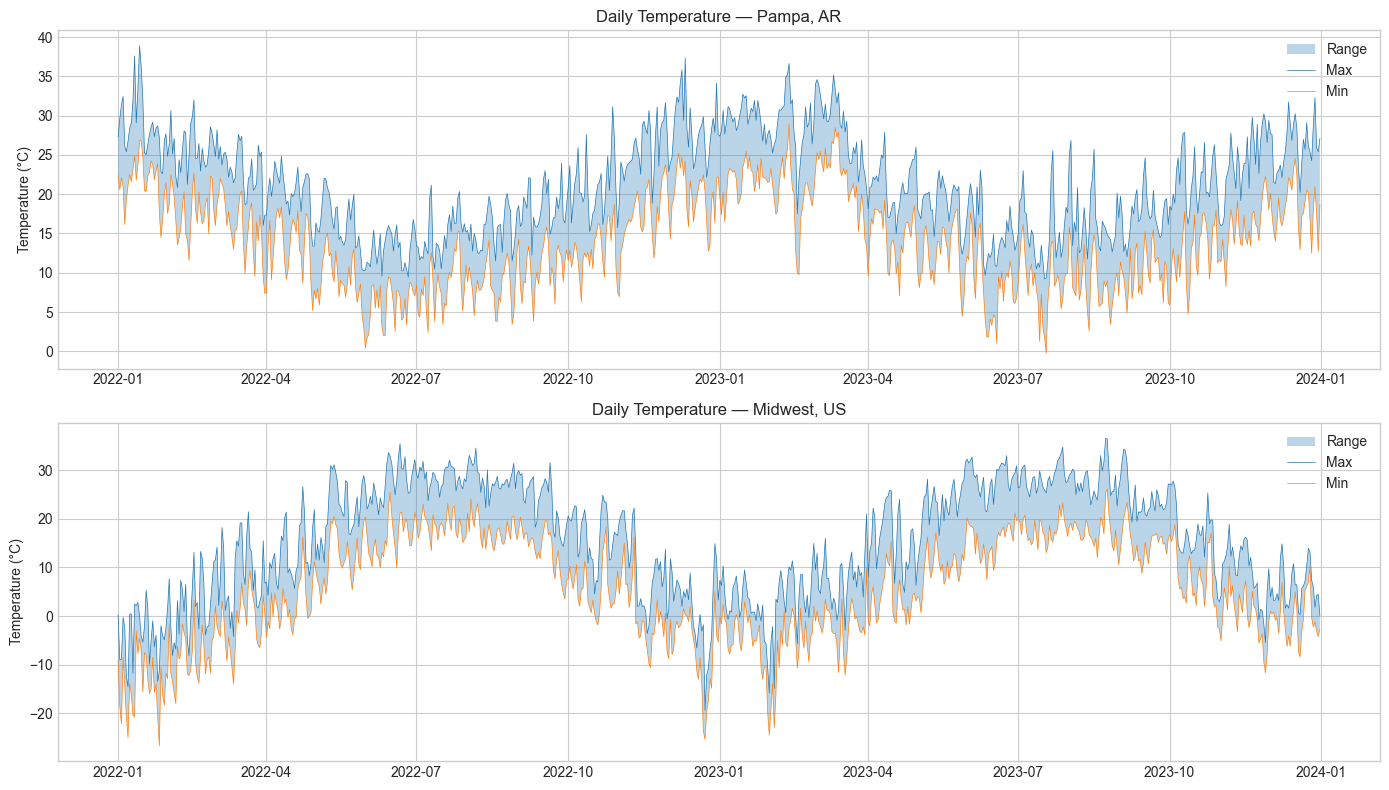

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

for ax, df, name in [(axes[0], df_pampa, "Pampa, AR"), (axes[1], df_midwest, "Midwest, US")]:
    ax.fill_between(df.index, df["temperature_2m_min"], df["temperature_2m_max"], alpha=0.3, label="Range")
    ax.plot(df.index, df["temperature_2m_max"], linewidth=0.5, label="Max")
    ax.plot(df.index, df["temperature_2m_min"], linewidth=0.5, label="Min")
    ax.set_ylabel("Temperature (°C)")
    ax.set_title(f"Daily Temperature — {name}")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

### 3.2 Precipitation

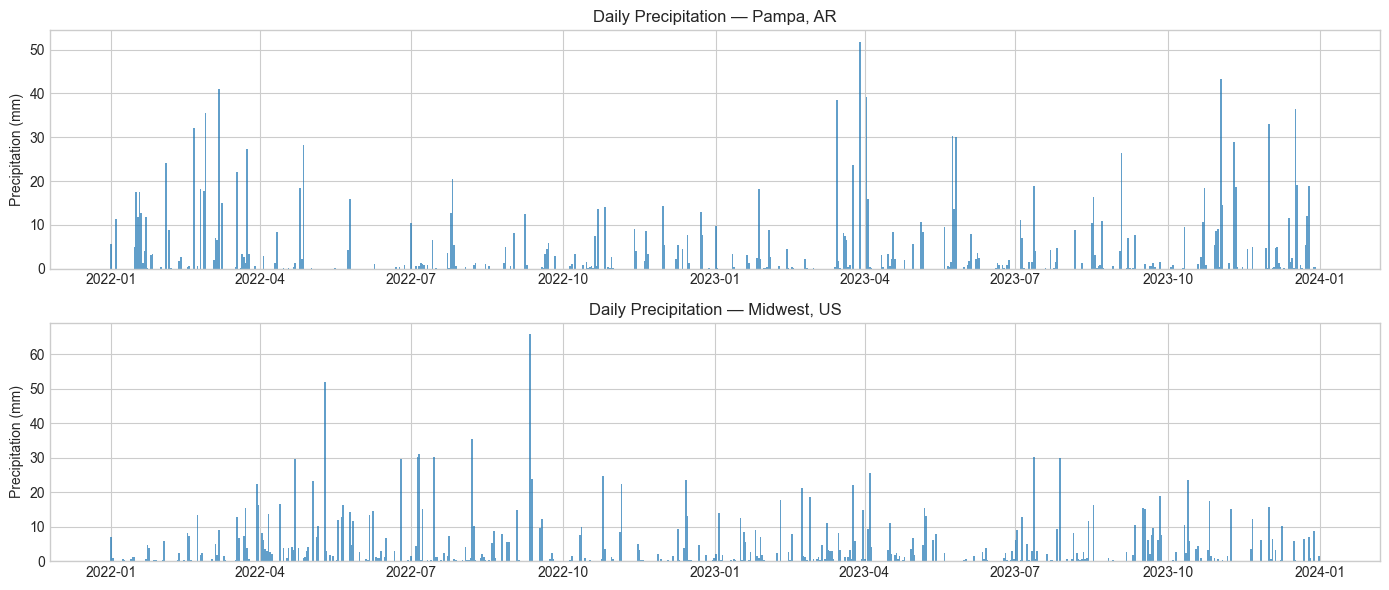

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

for ax, df, name in [(axes[0], df_pampa, "Pampa, AR"), (axes[1], df_midwest, "Midwest, US")]:
    ax.bar(df.index, df["precipitation_sum"], width=1, alpha=0.7)
    ax.set_ylabel("Precipitation (mm)")
    ax.set_title(f"Daily Precipitation — {name}")

plt.tight_layout()
plt.show()

### 3.3 Soil Moisture

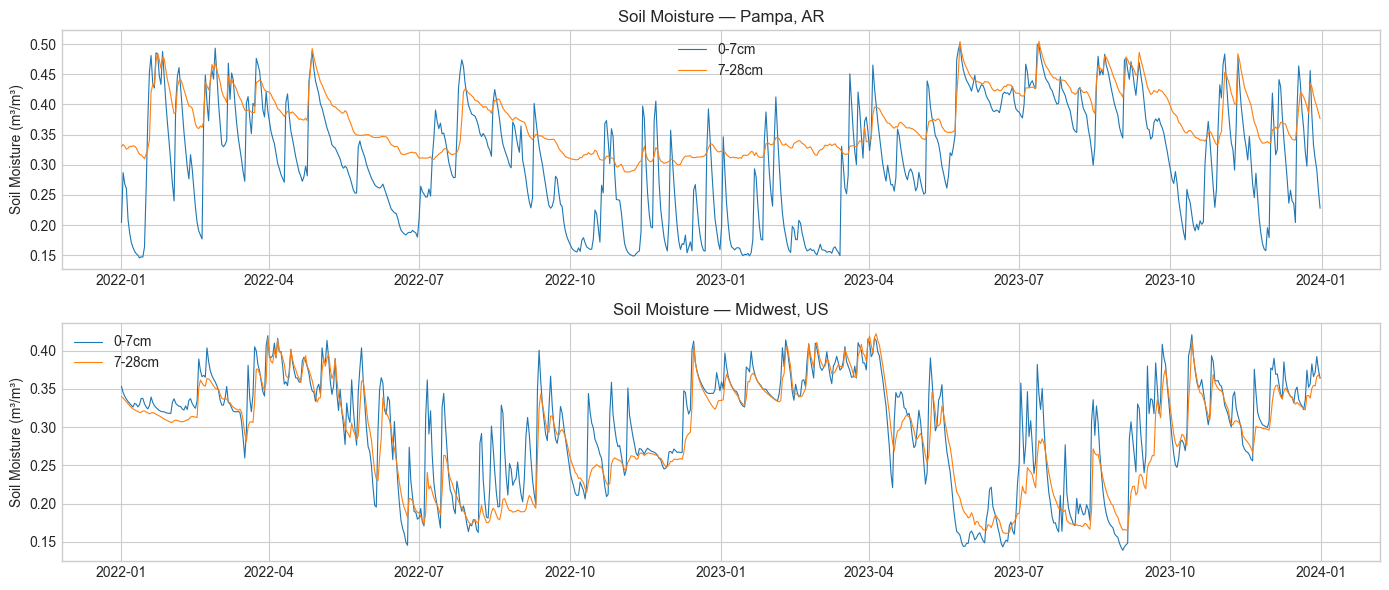

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

for ax, df, name in [(axes[0], df_pampa, "Pampa, AR"), (axes[1], df_midwest, "Midwest, US")]:
    ax.plot(df.index, df["soil_moisture_0_to_7cm_mean"], label="0-7cm", linewidth=0.8)
    ax.plot(df.index, df["soil_moisture_7_to_28cm_mean"], label="7-28cm", linewidth=0.8)
    ax.set_ylabel("Soil Moisture (m³/m³)")
    ax.set_title(f"Soil Moisture — {name}")
    ax.legend()

plt.tight_layout()
plt.show()

### 3.4 Evapotranspiration vs Precipitation

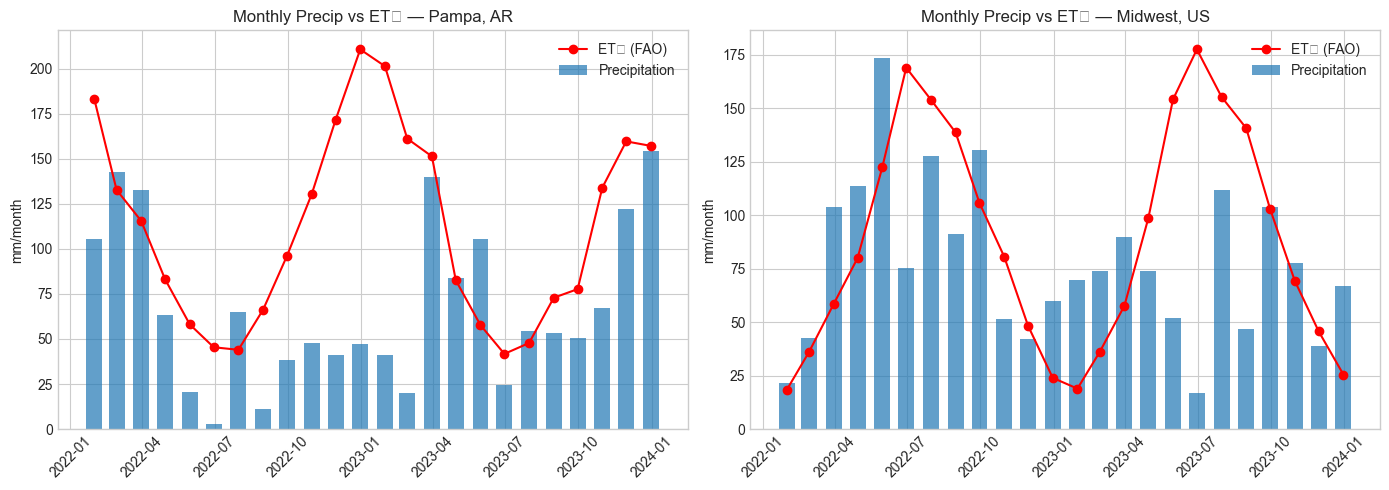

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, name in [(axes[0], df_pampa, "Pampa, AR"), (axes[1], df_midwest, "Midwest, US")]:
    monthly = df[["precipitation_sum", "et0_fao_evapotranspiration"]].resample("ME").sum()
    ax.bar(monthly.index, monthly["precipitation_sum"], width=20, alpha=0.7, label="Precipitation")
    ax.plot(monthly.index, monthly["et0_fao_evapotranspiration"], color="red", marker="o", label="ET₀ (FAO)")
    ax.set_ylabel("mm/month")
    ax.set_title(f"Monthly Precip vs ET₀ — {name}")
    ax.legend()
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 4. Correlation Matrix

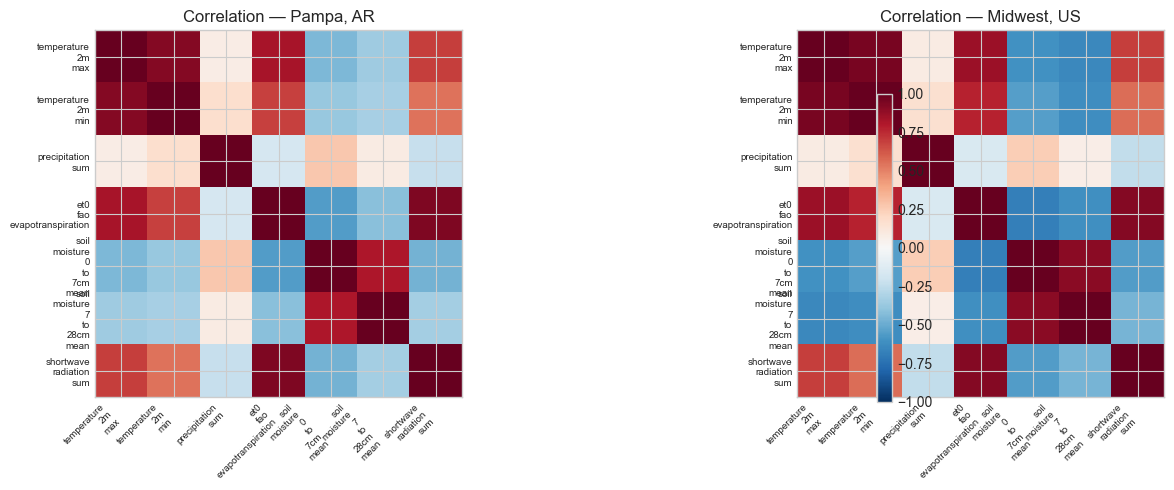

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, name in [(axes[0], df_pampa, "Pampa, AR"), (axes[1], df_midwest, "Midwest, US")]:
    corr = df.corr()
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    labels = [c.replace("_", "\n") for c in corr.columns]
    ax.set_xticklabels(labels, fontsize=7, rotation=45, ha="right")
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(f"Correlation — {name}")

fig.colorbar(im, ax=axes, shrink=0.8)
plt.tight_layout()
plt.show()

## 5. Findings & Limitations

### Findings
- **Coverage**: complete. Both locations returned exactly `(730, 7)` for 2022-01-01 → 2023-12-31 — all 730 days present, no gaps.
- **Missing values**: none. `isnull().sum()` is 0 for all seven variables at both locations.
- **Seasonal patterns**: as expected and correctly anti-phased between hemispheres — Pampa peaks in Dec-Feb, the Midwest in Jun-Aug. Temperature ranges are physically sound (Pampa 9.2-38.9 °C max; Midwest -19.4-36.6 °C max, with a much wider continental spread).
- **Soil moisture**: within 0.14-0.50 m³/m³ everywhere. The Pampa 0-7cm layer is far spikier than 7-28cm and repeatedly flattens at its 0.15 m³/m³ floor, while the two Midwest layers track each other closely.
- **Soil moisture vs precipitation**: *not* the expected relationship. Daily precipitation is the weakest-correlated variable in the matrix — near zero against same-day soil moisture. The strong structure is temperature/ET₀/radiation correlating positively with each other and negatively with both soil layers. Same-day rainfall is therefore a poor proxy for soil water; lagged or accumulated precipitation is needed.

### Limitations
- ERA5 reanalysis data has ~9km resolution — does not capture micro-climate variation within a farm
- Recent ERA5 data (last 5-7 days) may have gaps until fully processed
- Soil moisture values are modeled, not measured — ground-truth validation would be needed
- **Correlation ≠ causation**: Climate data alone does not predict crop yields — agronomic, economic, and social factors are critical

### Decision Gate

**Decision: proceed to designing risk scenarios on Archive data — do not detour into the Climate API yet.**

Coverage and quality are sufficient to build on: 730/730 days with zero NaNs at both locations, all values inside physical bounds, and correctly phased seasonality. The one substantive gap is analytical rather than a data gap — same-day precipitation does not explain soil moisture — so the next step is to derive lagged/accumulated water-balance indicators (precipitation minus ET₀ over rolling windows) from this same Archive data, rather than adding a new endpoint.
